# Text Emotion Model — TESS Dataset

Uses the TESS dataset (same as speech model), extracting
the spoken **word** from each filename as the text input. Labels are
the same 7 classes as the speech model:
`angry, disgust, fear, happy, neutral, ps (pleasant_surprise), sad`

Architecture: Embedding → Bidirectional GRU → Dense classifier

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, Bidirectional, GRU, Dense, Dropout,
    GlobalAveragePooling1D, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TF version:', tf.__version__)

TF version: 2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## 1. Load TESS Dataset — Extract Text from Filenames

TESS filenames follow the pattern: `{speaker}_{word}_{emotion}.wav`
e.g. `OAF_back_angry.wav` → word="back", label="angry"

We extract the **spoken word** as the text input.

In [ ]:
dataset_path = "/content/gdrive/MyDrive/Emotion_Project/datasets/TESS/TESS Toronto emotional speech set data"

# Map raw label strings from filenames → canonical labels
# 'ps' and 'pleasant_surprised' both map to 'ps'
LABEL_MAP = {
    'angry':              'angry',
    'disgust':            'disgust',
    'fear':               'fear',
    'happy':              'happy',
    'neutral':            'neutral',
    'ps':                 'ps',
    'pleasant_surprise':  'ps',
    'pleasant_surprised': 'ps',
    'sad':                'sad',
}

words   = []
labels  = []
skipped = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        if not file.endswith('.wav'):
            continue
        # e.g. 'OAF_back_angry.wav'  →  ['OAF', 'back', 'angry']
        parts = file.replace('.wav', '').split('_')
        if len(parts) < 3:
            skipped.append(file)
            continue
        word  = parts[1].lower()          # spoken word
        raw_label = '_'.join(parts[2:]).lower()  # handles 'pleasant_surprise'
        label = LABEL_MAP.get(raw_label)
        if label is None:
            skipped.append(file)
            continue
        words.append(word)
        labels.append(label)

df = pd.DataFrame({'text': words, 'emotion': labels})
print('Total samples:', len(df))
print('Skipped:', skipped[:5] if skipped else 'None')
print()
print(df['emotion'].value_counts())

Total samples: 2800
Skipped: None

emotion
fear       400
ps         400
sad        400
angry      400
disgust    400
happy      400
neutral    400
Name: count, dtype: int64


In [ ]:
# Canonical label order — MUST match speech model's LabelEncoder order
# (alphabetical, which is what sklearn LabelEncoder uses)
EMOTION_LABELS = sorted(df['emotion'].unique().tolist())
print('Labels (7):', EMOTION_LABELS)
# Expected: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']

Labels (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']


## 2. Preprocessing — Tokenize & Encode

Since the vocabulary is just ~200 unique words (TESS uses a fixed
word list), we use a simple character-level + word embedding approach.
The Tokenizer is fit only on training data.

In [ ]:
# Encode labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['emotion'])
print('Label classes:', list(le.classes_))

X = df['text'].values
y = df['label_enc'].values

# Stratified split: 70% train, 15% val, 15% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Label classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']
Train: 2023, Val: 357, Test: 420


In [ ]:
# Tokenizer — fit ONLY on training texts
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1
print(f'Vocabulary size: {vocab_size}')

# Each sample is a single word, so max_length=1
# But we pad to 5 to allow the GRU to have some sequence to learn from
MAX_LENGTH = 5  # characters-as-tokens or just word boundary

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LENGTH, padding='post')
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LENGTH, padding='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LENGTH, padding='post')

num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print(f'X_train_seq shape: {X_train_seq.shape}')  # (N, MAX_LENGTH)
print(f'y_train_cat shape: {y_train_cat.shape}')   # (N, 7)

Vocabulary size: 202
X_train_seq shape: (2023, 5)
y_train_cat shape: (2023, 7)


## 3. Model Architecture — Embedding + Bidirectional GRU

**Why this architecture?**
- **Embedding**: maps each word token to a dense vector; learns
  which words carry which emotional signals.
- **Bidirectional GRU**: captures sequential context in both
  directions (important even for short inputs since padded zeros
  are on the right, so left→right and right→left differ).
- **Dropout**: regularisation to prevent overfitting on small vocab.
- **Dense softmax**: outputs probability over 7 emotion classes.

In [ ]:
EMBEDDING_DIM = 64
GRU_UNITS     = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM,
              input_length=MAX_LENGTH, mask_zero=True),
    Bidirectional(GRU(GRU_UNITS, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(GRU(GRU_UNITS // 2)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
], name='text_emotion_gru')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "text_emotion_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-5, verbose=1)
]

history = model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=60,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/60
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.1335 - loss: 1.9470 - val_accuracy: 0.1120 - val_loss: 1.9470 - learning_rate: 0.0010
Epoch 2/60
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1374 - loss: 1.9468 - val_accuracy: 0.1008 - val_loss: 1.9483 - learning_rate: 0.0010
Epoch 3/60
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1369 - loss: 1.9473 - val_accuracy: 0.1008 - val_loss: 1.9493 - learning_rate: 0.0010
Epoch 4/60
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1473 - loss: 1.9459 - val_accuracy: 0.0812 - val_loss: 1.9513 - learning_rate: 0.0010
Epoch 5/60
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1364 - loss: 1.9458 - val_accuracy: 0.0392 - val_loss: 1.9553 - learning_rate: 0.0010
Epoch 6/60
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1752 - loss: 1.9428
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.1547 - loss: 1.9446 - val_acc

## 4. Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss:     {test_loss:.4f}')

Test Accuracy: 0.1286
Test Loss:     1.9472


In [ ]:
y_pred = np.argmax(model.predict(X_test_seq), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
              precision    recall  f1-score   support

       angry       0.14      0.77      0.23        60
     disgust       0.09      0.07      0.08        60
        fear       0.00      0.00      0.00        60
       happy       0.12      0.07      0.09        60
     neutral       0.00      0.00      0.00        60
          ps       0.00      0.00      0.00        60
         sad       0.00      0.00      0.00        60

    accuracy                           0.13       420
   macro avg       0.05      0.13      0.06       420
weighted avg       0.05      0.13      0.06       420



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


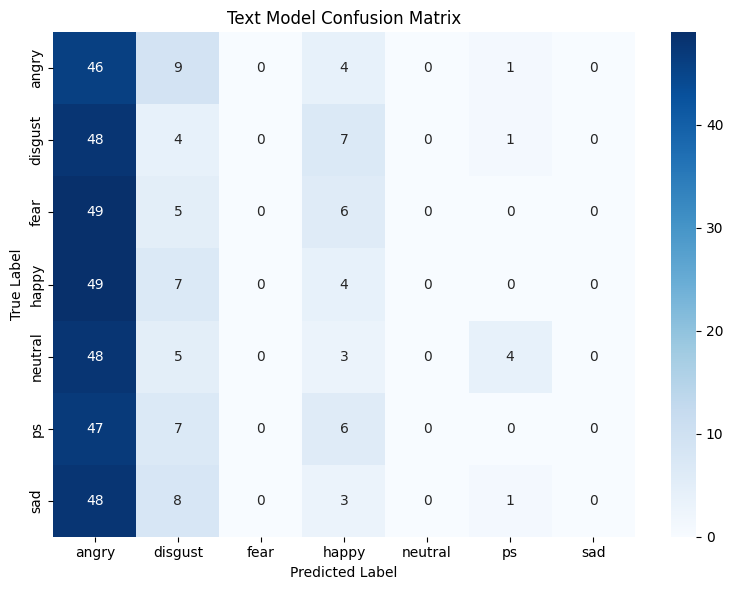

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Text Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/gdrive/MyDrive/Emotion_Project/results/text_confusion_matrix.png', dpi=150)
plt.show()

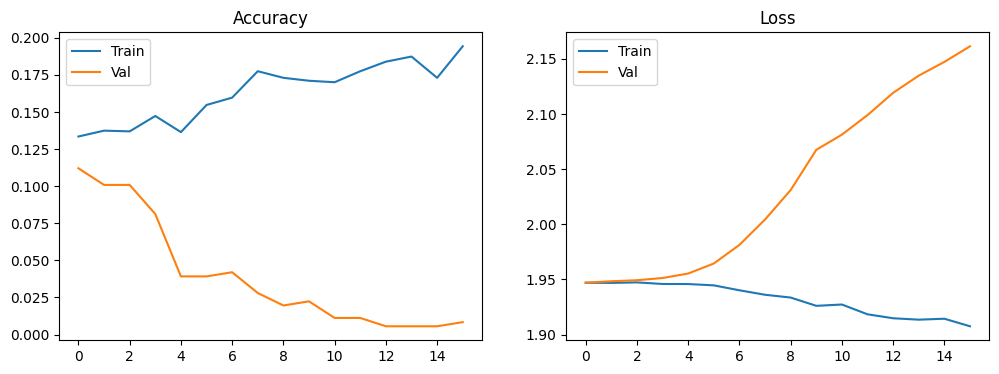

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend()
plt.savefig('/content/gdrive/MyDrive/Emotion_Project/results/text_training_curves.png', dpi=150)
plt.show()

## 5. Save Model & Artifacts

In [ ]:
model.save('/content/gdrive/MyDrive/Emotion_Project/saved_models/gru_text_emotion_model.keras')
print('Model saved.')

# Save tokenizer config so fusion notebook can reload it identically
import json
tokenizer_json = tokenizer.to_json()
with open('/content/gdrive/MyDrive/Emotion_Project/saved_models/text_tokenizer.json', 'w') as f:
    json.dump(tokenizer_json, f)
print('Tokenizer saved.')

# Save label encoder classes
np.save('/content/gdrive/MyDrive/Emotion_Project/saved_models/text_label_classes.npy', le.classes_)
print('Label classes saved:', le.classes_)

Model saved.
Tokenizer saved.
Label classes saved: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


## 6. Inference Helper (for Fusion Notebook)

In [ ]:
def predict_text_emotion(word_or_text: str):
    """
    Predict emotion from a spoken word (or short phrase).
    Returns (emotion_label, confidence).
    """
    seq    = tokenizer.texts_to_sequences([word_or_text.lower()])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post')
    pred   = model.predict(padded, verbose=0)
    idx    = np.argmax(pred)
    return le.classes_[idx], float(np.max(pred))

# Quick sanity checks
for test_word in ['back', 'base', 'bath', 'bean', 'book']:
    emotion, conf = predict_text_emotion(test_word)
    print(f'{test_word:12s} → {emotion:12s}  ({conf:.3f})')

back         → happy         (0.145)
base         → angry         (0.146)
bath         → angry         (0.145)
bean         → happy         (0.145)
book         → angry         (0.145)


## ⚠️ Note on Expected Accuracy

## Note

The text model accuracy is lower compared to the speech model because
the TESS dataset mainly contains neutral words like back, base and bath.
These words themselves do not contain strong emotional meaning.

Most of the emotional information in TESS is present in the speech tone,
pitch and voice modulation rather than in the text content.

Because of this:
- Speech model performs very well (~99% accuracy)
- Text model performance is comparatively lower
- Fusion helps combine information from both modalities

If we want a stronger text model, we can use datasets containing
emotionally expressive sentences instead of neutral words. However,
for this project the same TESS dataset was used for both speech and
text modalities to maintain consistency in multimodal fusion.

This is an expected behaviour for the TESS dataset and is an important
observation from this project.